h = 0.1
Amplification factor = -99.0
Solution may not be Entirely Stable ;)
--------------------------------------------------


<ipython-input-2-8bcd89fd1be0>:5: RuntimeWarning: overflow encountered in double_scalars
  return -1000 * y + 3000 - 2000 * np.exp(-t)
<ipython-input-2-8bcd89fd1be0>:34: RuntimeWarning: invalid value encountered in double_scalars
  y[n + 1] = y[n] + h * f(t[n], y[n])


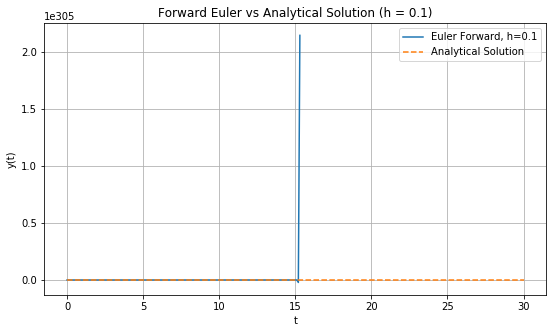

h = 0.01
Amplification factor = -9.0
Solution may not be Entirely Stable ;)
--------------------------------------------------


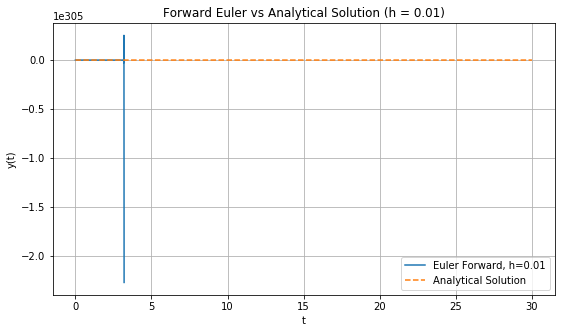

h = 0.001
Amplification factor = 0.0
Solution is Stable
--------------------------------------------------


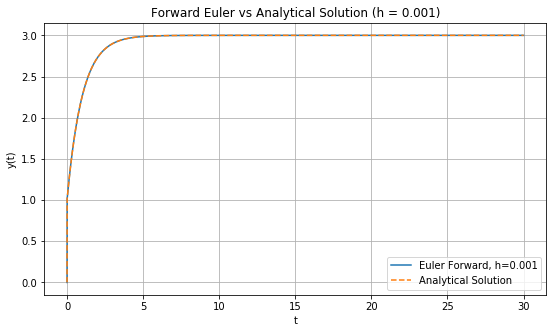

h = 1e-05
Amplification factor = 0.99
Solution is Stable
--------------------------------------------------
Skipping plot for h = 1e-05 because it needs 3000000 points.

h = 1e-07
Amplification factor = 0.9999
Solution is Stable
--------------------------------------------------
Skipping plot for h = 1e-07 because it needs 300000001 points.



In [2]:
import numpy as np
import matplotlib.pyplot as plt

def f(t, y):
    return -1000 * y + 3000 - 2000 * np.exp(-t)

def y_exact(t):
    return 3 - 0.998 * np.exp(-1000 * t) - 2.002 * np.exp(-t)

h_values = [0.1, 0.01, 0.001, 0.00001, 0.0000001]
t0 = 0.0
tf = 30.0
y0 = 0.0

max_points_to_store = 2_000_000

for h in h_values:
    amp = 1 - 1000 * h
    stable = abs(amp) < 1

    print(f"h = {h}")
    print(f"Amplification factor = {amp}")
    print("Solution is Stable" if stable else "Solution may not be Entirely Stable ;)")
    print("-" * 50)

    n_steps = int((tf - t0) / h)

    if n_steps + 1 <= max_points_to_store:
        t = np.linspace(t0, tf, n_steps + 1)
        y = np.zeros(n_steps + 1)
        y[0] = y0

        for n in range(n_steps):
            y[n + 1] = y[n] + h * f(t[n], y[n])

        y_true = y_exact(t)

        plt.figure(figsize=(9, 5))
        plt.plot(t, y, label=f"Euler Forward, h={h}")
        plt.plot(t, y_true, '--', label="Analytical Solution")
        plt.xlabel("t")
        plt.ylabel("y(t)")
        plt.title(f"Forward Euler vs Analytical Solution (h = {h})")
        plt.grid(True)
        plt.legend()
        plt.show()
    else:
        print(f"Skipping plot for h = {h} because it needs {n_steps + 1} points.")
        print()